In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_42_53.877/Mrk-544_MAPPED_FLUX_SCI_LSS_U2.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_42_53.877/Mrk-544_MAPPED_FLUX_SCI_LSS_U2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     369   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        50   (2094, 964)   float32   


In [4]:
image_cut = image[55:155, 0:1800]
image_error_cut = image_error[55:155, 0:1800]

In [5]:
image_error_cut

array([[0.0301985 , 0.0298051 , 0.02746327, ..., 0.00679511, 0.00622579,
        0.00635145],
       [0.02926593, 0.02896057, 0.02864649, ..., 0.00628732, 0.00656953,
        0.00666576],
       [0.02915833, 0.02923965, 0.03022192, ..., 0.00660786, 0.00671982,
        0.00653776],
       ...,
       [0.02788196, 0.02832108, 0.02692269, ..., 0.00636282, 0.0064038 ,
        0.00636289],
       [0.02935763, 0.02965136, 0.02743452, ..., 0.0064402 , 0.00651467,
        0.00659298],
       [0.02940499, 0.02915512, 0.02936518, ..., 0.00677424, 0.00656252,
        0.00643195]], dtype='>f4')

Text(0.5, 0, 'wavelenght')

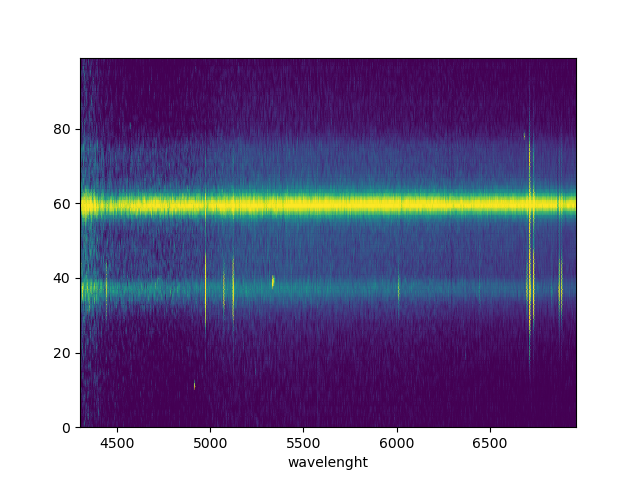

In [6]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

## Redshift or the lines in air

In [7]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [8]:
l_HA

6719.1994

## Continuum

0.0012842314
5.852023e-06
0.025367284


Text(0.5, 1.0, 'Continuum 3')

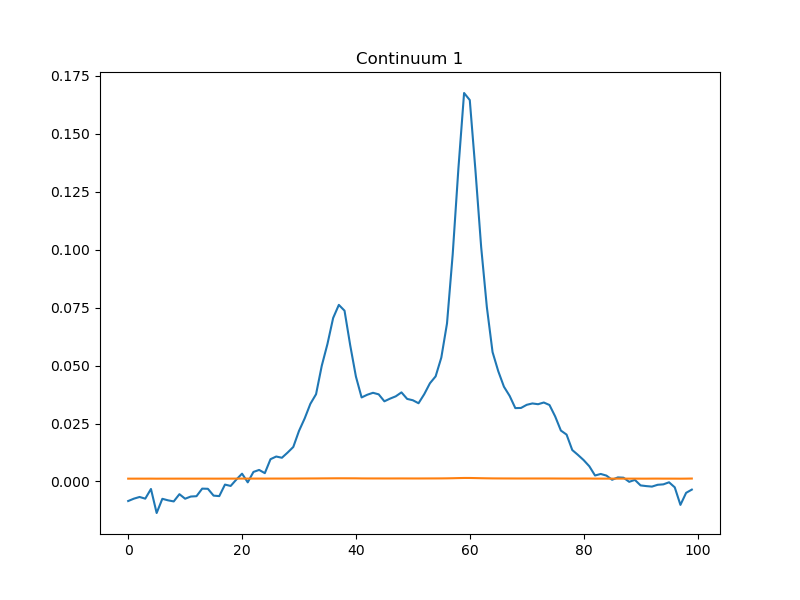

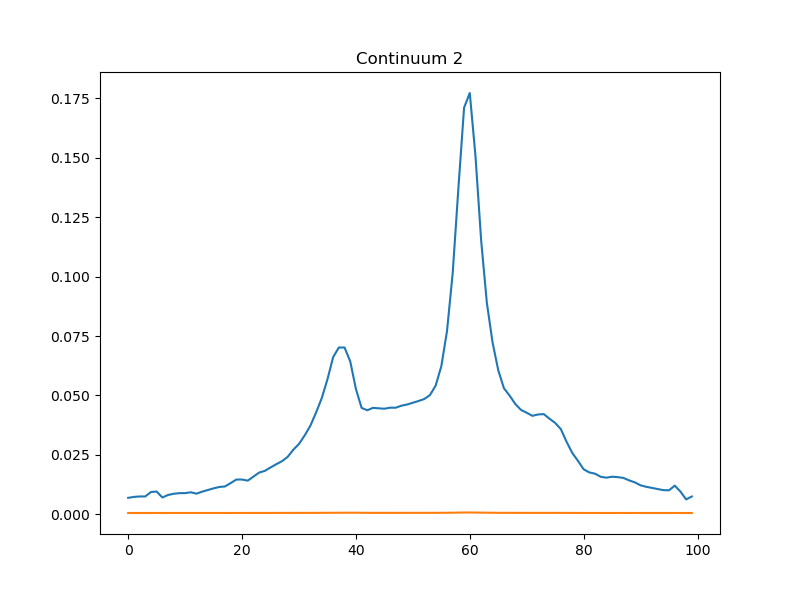

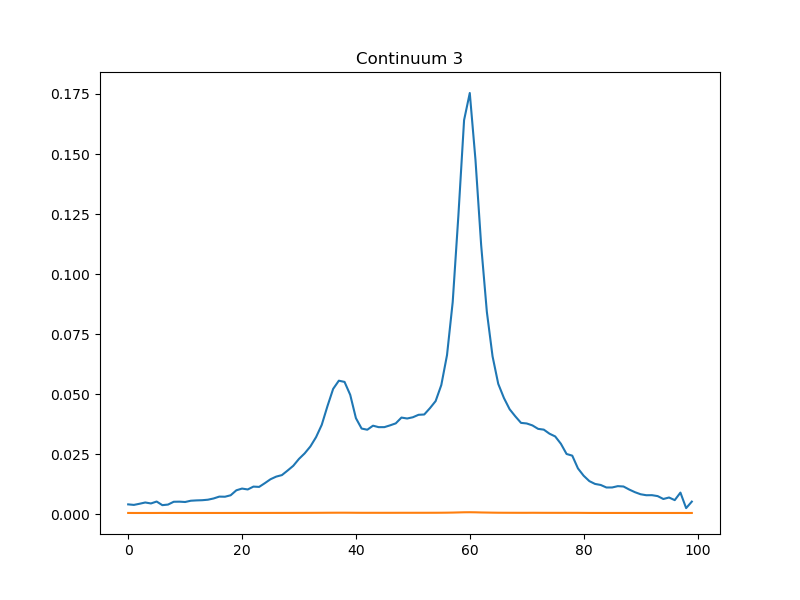

In [56]:
mask_continuum_1 = (wavelenghts > 4500)*(wavelenghts < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.mean(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))/image_error_continuum_1.shape[1]
error_mean = np.std(image_error_continuum_1, axis=1)/image_error_continuum_1.shape[1]
print(np.mean(radial_profile_error_continuum_1))
print(np.mean(error_mean))
print(np.mean(radial_profile_continuum_1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

mask_continuum_2 = (wavelenghts > 5300)*(wavelenghts < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.mean(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))/image_error_continuum_2.shape[1]

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

mask_continuum_3 = (wavelenghts > 6400)*(wavelenghts < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.mean(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))/image_error_continuum_3.shape[1]

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

## Sky lines

In [10]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[55:155, 0:1800]

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


Text(0.5, 36.72222222222221, 'wavelenght')

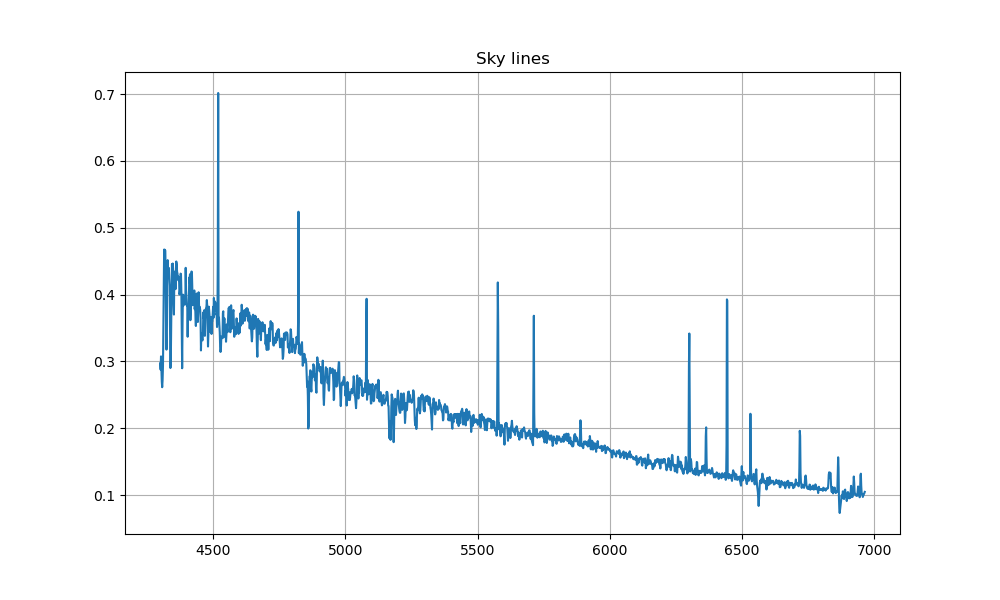

In [11]:
mask_sky = (y > 15)*(y < 25)
image_sky = image_cut2[mask_sky, :]
radial_profile_sky = np.mean(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wavelenghts, radial_profile_sky)
#x_interval = np.arange(4300, 4300+1800*1.48, 250)
#plt.xticks(x_interval)
plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

In [52]:
image_error_HA
image_error_HA.shape

(100, 13)

In [ ]:
e

array([[0.00707829, 0.00736355, 0.00707215, ..., 0.00717294, 0.00705208,
        0.00715945],
       [0.00698216, 0.00746062, 0.00717582, ..., 0.00714536, 0.00670628,
        0.00719217],
       [0.0069439 , 0.00703723, 0.00699095, ..., 0.00700045, 0.00692216,
        0.00699644],
       ...,
       [0.00706878, 0.0070081 , 0.00700334, ..., 0.00710049, 0.00697229,
        0.0072285 ],
       [0.00694575, 0.00695015, 0.00692171, ..., 0.00696611, 0.00723251,
        0.00675559],
       [0.00720115, 0.00659457, 0.00671164, ..., 0.00693014, 0.00705171,
        0.00743345]], dtype='>f4')

0.002683032
0.0001742559
0.120343626


Text(0.5, 1.0, 'H$\\alpha$')

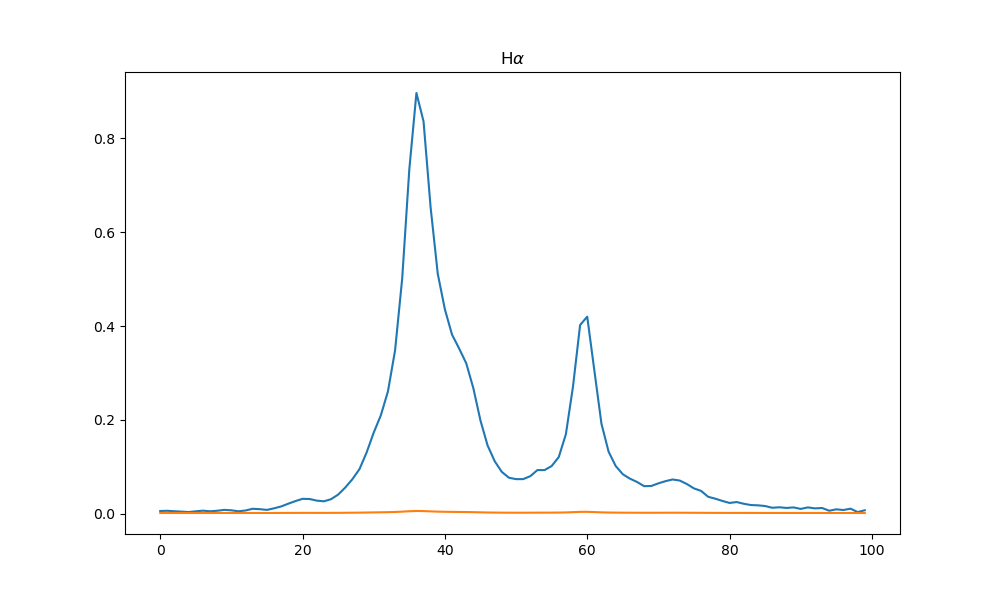

In [55]:
#Ogni punto del flusso è il risultato della media di 20 lunghezze d'onda, otteniamo l'errore come std della media
mask_HA = (wavelenghts > l_HA-10)*(wavelenghts < l_HA+10)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.mean(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))/image_error_HA.shape[1]
error_mean = np.std(image_error_HA, axis=1)/image_error_HA.shape[1]
print(np.mean(radial_profile_error_HA))
print(np.mean(error_mean))
print(np.mean(radial_profile_HA))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [13]:
np.sqrt(np.sum(image_error_HA[0]**2))/len(image_error_HA[0])
image_error_HA.shape[1]

13

In [14]:
image_error_HA[:, 7]

array([0.00699524, 0.00706735, 0.00709999, 0.00697547, 0.00673852,
       0.00683478, 0.00723645, 0.00725393, 0.00715956, 0.00711385,
       0.00715344, 0.00719377, 0.0071451 , 0.00730243, 0.00749038,
       0.00730208, 0.00742457, 0.00756888, 0.00745009, 0.00770321,
       0.00810253, 0.00816367, 0.00813704, 0.00799054, 0.00833978,
       0.00906951, 0.00985993, 0.01037622, 0.01073659, 0.01163994,
       0.01278338, 0.01383566, 0.01499505, 0.01716063, 0.02091122,
       0.02558944, 0.02800015, 0.02612521, 0.02266103, 0.02050352,
       0.01901895, 0.0180396 , 0.01738274, 0.01697544, 0.01617941,
       0.014284  , 0.01239127, 0.01116146, 0.01065329, 0.00997738,
       0.00968377, 0.00946237, 0.00954907, 0.00983657, 0.01017066,
       0.01085161, 0.01167119, 0.01331148, 0.01666671, 0.02051978,
       0.02062482, 0.01728272, 0.01403482, 0.01222073, 0.0111549 ,
       0.01052072, 0.01007845, 0.00940125, 0.0088914 , 0.00900913,
       0.00888031, 0.00917141, 0.00906284, 0.00882179, 0.00832

In [15]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (50, 70),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2.641083044750324
differential_evolution step 2: f(x)= 1.8152627815388063
differential_evolution step 3: f(x)= 1.115458836042231
differential_evolution step 4: f(x)= 1.115458836042231
differential_evolution step 5: f(x)= 1.115458836042231
differential_evolution step 6: f(x)= 0.42368835998604787
differential_evolution step 7: f(x)= 0.42368835998604787
differential_evolution step 8: f(x)= 0.42368835998604787
differential_evolution step 9: f(x)= 0.42368835998604787
differential_evolution step 10: f(x)= 0.42368835998604787
differential_evolution step 11: f(x)= 0.42368835998604787
differential_evolution step 12: f(x)= 0.42368835998604787
differential_evolution step 13: f(x)= 0.42368835998604787
differential_evolution step 14: f(x)= 0.42368835998604787
differential_evolution step 15: f(x)= 0.42368835998604787
differential_evolution step 16: f(x)= 0.3621543015464724
differential_evolution step 17: f(x)= 0.3621543015464724
differential_evolution step 18: f(

In [1]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

plt.savefig('Radial_profile_Halpha_diff')

NameError: name 'np' is not defined

In [ ]:
params_curve_HA, covariance_HA = curve_fit(model_convolved, x_axes, radial_profile_HA, p0=result.x, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0_HA = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0_HA[i] = params_curve_HA[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_HA)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0_HA[i]:.4f}")

print(np.sqrt(np.diag(covariance_HA)))
#print(infodict.fvec**2)
chi2_HA = np.sum((((radial_profile_HA - model_convolved(x_axes, *params_curve_HA)) / radial_profile_error_HA)**2))
dof_HA = len(radial_profile_HA) - len(params_curve_HA)
chi2_reduced_HA = chi2_HA / dof_HA
print(chi2_reduced_HA)

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0_HA, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Halpha_fit.csv", index= False, float_format='%.4f')

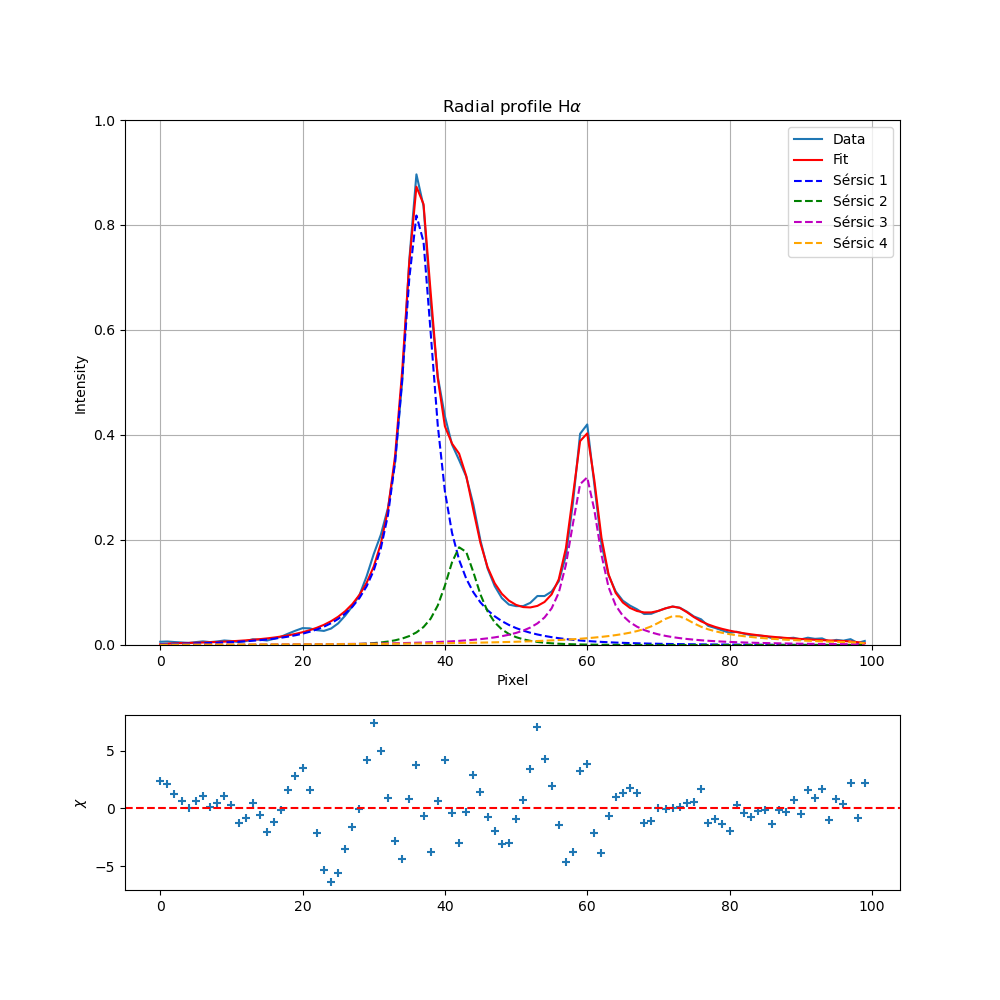

In [18]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_HA)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].scatter(x_axes, (radial_profile_HA - y_fit)/radial_profile_error_HA, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')

plt.savefig('Radial_profile_Halpha_curve')

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

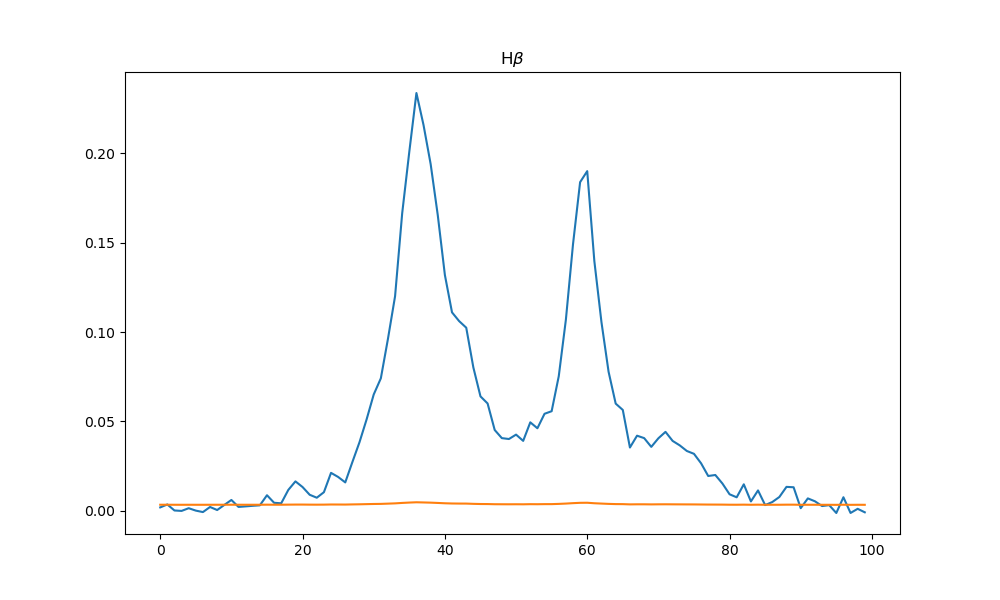

In [19]:
mask_HB = (wavelenghts > l_HB-10)*(wavelenghts < l_HB+10)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.mean(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))/image_error_HB.shape[1]

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [20]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 0.9881326648149872
differential_evolution step 2: f(x)= 0.20494123871136039
differential_evolution step 3: f(x)= 0.20494123871136039
differential_evolution step 4: f(x)= 0.20494123871136039
differential_evolution step 5: f(x)= 0.20494123871136039
differential_evolution step 6: f(x)= 0.20494123871136039
differential_evolution step 7: f(x)= 0.1447767561077491
differential_evolution step 8: f(x)= 0.1447767561077491
differential_evolution step 9: f(x)= 0.1447767561077491
differential_evolution step 10: f(x)= 0.1447767561077491
differential_evolution step 11: f(x)= 0.1447767561077491
differential_evolution step 12: f(x)= 0.1447767561077491
differential_evolution step 13: f(x)= 0.1447767561077491
differential_evolution step 14: f(x)= 0.07825790771569348
differential_evolution step 15: f(x)= 0.07825790771569348
differential_evolution step 16: f(x)= 0.06421542542799731
differential_evolution step 17: f(x)= 0.026249451819101585
differential_evolution step 18

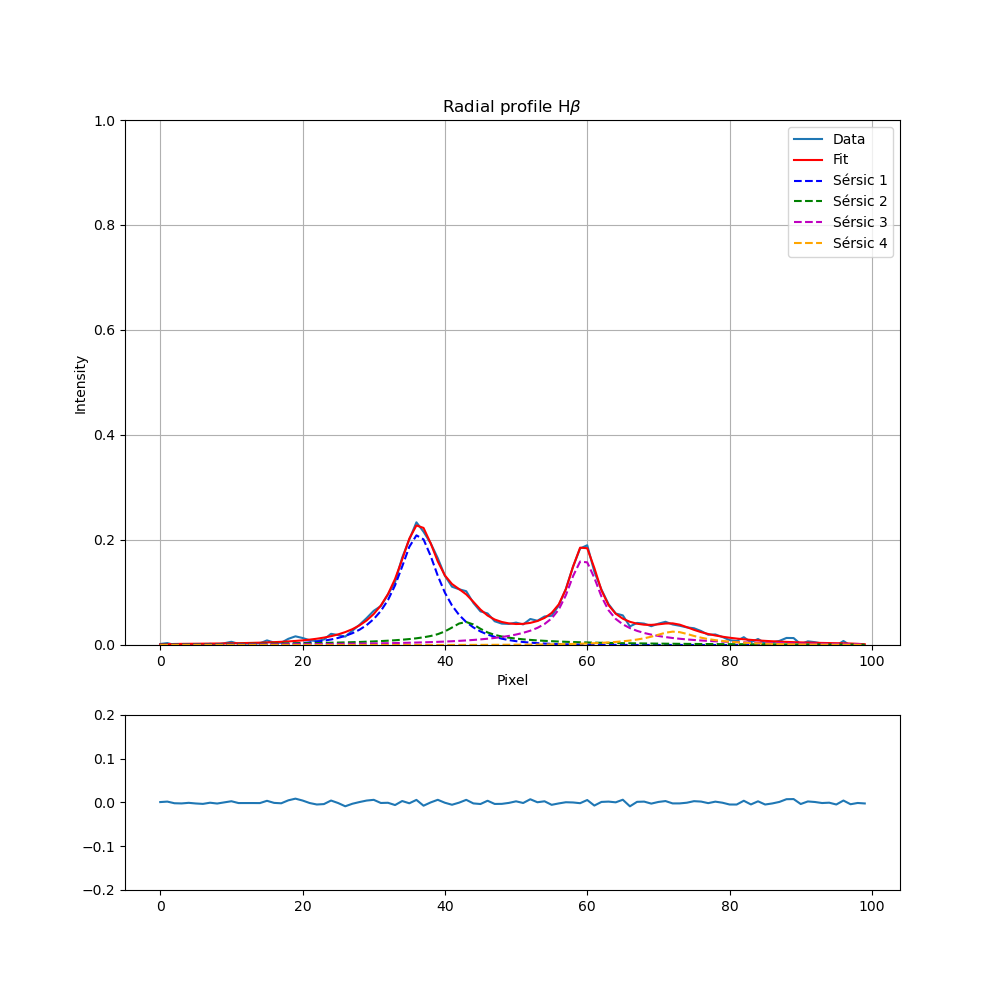

In [21]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HB, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\beta$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0,1)

ax[1].plot(x_axes, radial_profile_HB - y_fit)
ax[1].set_ylim(-0.2, 0.2)
plt.savefig('Radial_profile_Hbeta_kernel')

In [22]:
params_curve_HB, covariance_HB = curve_fit(model_convolved, x_axes, radial_profile_HB, p0=result.x, sigma = radial_profile_error_HB)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_HB[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_HB)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("HBeta_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_HB)))
#print(infodict.fvec**2)
chi2_HB = np.sum((((radial_profile_HB - model_convolved(x_axes, *params_curve_HB)) / radial_profile_error_HB)**2))
dof_HB = len(radial_profile_HB) - len(params_curve_HB)
chi2_reduced_HB = chi2_HB / dof_HB
print(chi2_reduced_HB)

Sérsic 1: I_e=0.0442, r_e=6.4405, n=1.1106, x_0=36.2716
Sérsic 2: I_e=0.0010, r_e=48.1810, n=2.5210, x_0=42.8282
Sérsic 3: I_e=0.0044, r_e=24.2523, n=2.6900, x_0=59.4644
Sérsic 4: I_e=0.0043, r_e=9.6441, n=1.2049, x_0=72.1545
[6.00365445e-03 7.29474832e-01 1.00398638e-01 7.45493609e-02
 1.72635338e-03 8.21736956e+01 1.55185574e+00 2.73145219e-01
 1.18182185e-02 5.32464050e+01 2.22722063e+00 1.68098109e-02
 4.43257070e-03 1.23821703e+01 7.58852989e-01 4.28257001e-01]
1.1555438408120782


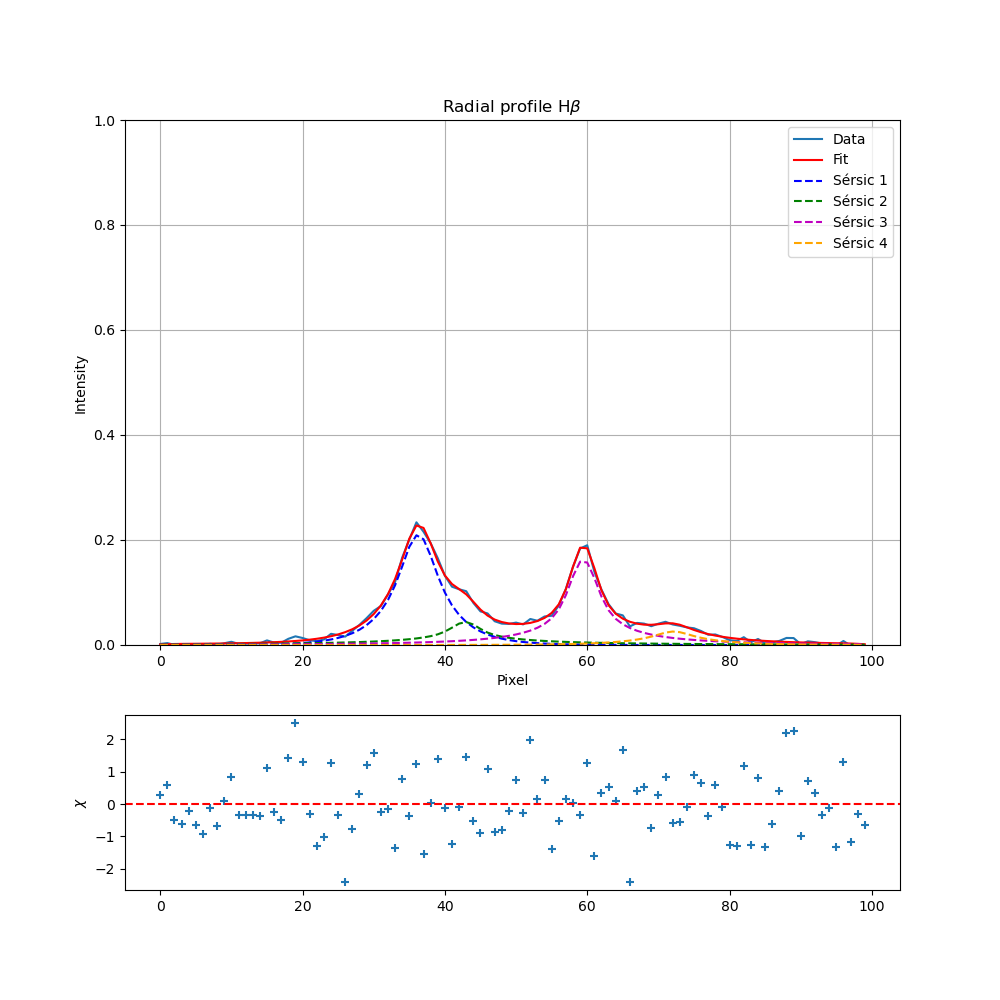

In [23]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_HB)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HB, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\beta$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].scatter(x_axes, (radial_profile_HB - y_fit)/radial_profile_error_HB, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

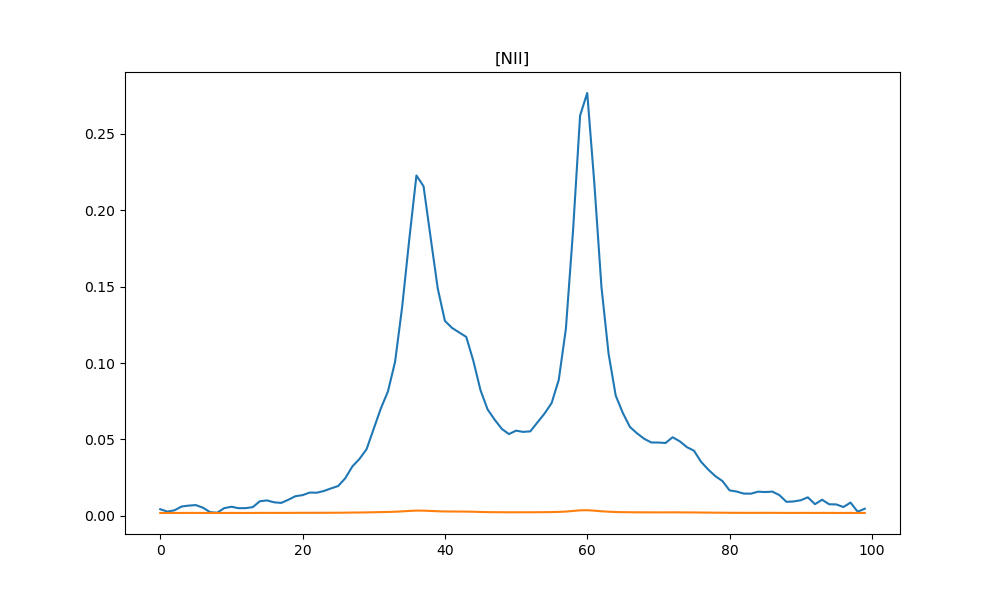

In [24]:
mask_NII = (wavelenghts > l_NII-10)*(wavelenghts < l_NII+10)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.mean(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))/image_error_NII.shape[1]
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [25]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 0.58024705644888
differential_evolution step 2: f(x)= 0.58024705644888
differential_evolution step 3: f(x)= 0.58024705644888
differential_evolution step 4: f(x)= 0.58024705644888
differential_evolution step 5: f(x)= 0.58024705644888
differential_evolution step 6: f(x)= 0.2753132822167613
differential_evolution step 7: f(x)= 0.2753132822167613
differential_evolution step 8: f(x)= 0.05376825122701002
differential_evolution step 9: f(x)= 0.05376825122701002
differential_evolution step 10: f(x)= 0.05376825122701002
differential_evolution step 11: f(x)= 0.05376825122701002
differential_evolution step 12: f(x)= 0.05376825122701002
differential_evolution step 13: f(x)= 0.05376825122701002
differential_evolution step 14: f(x)= 0.05376825122701002
differential_evolution step 15: f(x)= 0.05376825122701002
differential_evolution step 16: f(x)= 0.05376825122701002
differential_evolution step 17: f(x)= 0.05376825122701002
differential_evolution step 18: f(x)= 0.

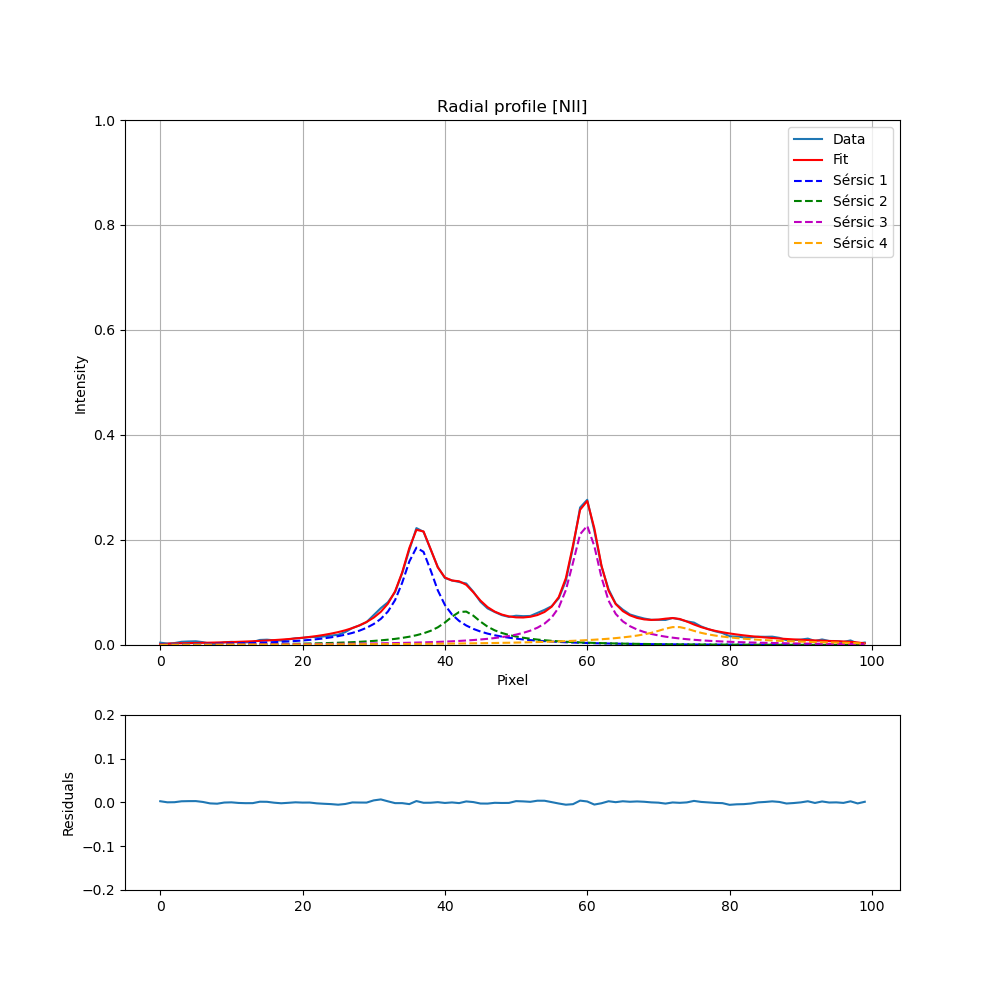

In [26]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_NII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [NII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].plot(x_axes, radial_profile_NII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')
plt.savefig('Radial_profile_NII_kernel')

In [27]:
params_curve_NII, covariance_NII = curve_fit(model_convolved, x_axes, radial_profile_NII, p0=result.x, sigma = radial_profile_error_NII)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_NII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_NII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("NII_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_NII)))
#print(infodict.fvec**2)
chi2_NII = np.sum((((radial_profile_NII - model_convolved(x_axes, *params_curve_NII)) / radial_profile_error_NII)**2))
dof_NII = len(radial_profile_NII) - len(params_curve_NII)
chi2_reduced_NII = chi2_NII / dof_NII
print(chi2_reduced_NII)

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5136\1605615470.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5136\1605615470.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.0130, r_e=12.6607, n=1.9297, x_0=36.3280
Sérsic 2: I_e=0.0047, r_e=16.5572, n=1.7870, x_0=42.6084
Sérsic 3: I_e=0.0035, r_e=29.8534, n=3.2483, x_0=59.7119
Sérsic 4: I_e=0.0019, r_e=37.1116, n=1.8277, x_0=72.5994
[5.57813365e-03 5.47763186e+00 2.92836349e-01 4.99751527e-02
 7.48459422e-03 3.20151689e+01 1.05974382e+00 1.64606422e-01
 1.35814684e-02 9.24871615e+01 3.31979637e+00 8.91216377e-04
 1.16641141e-03 3.99893643e+01 4.38409533e-01 2.89965821e-01]
1.203738891397761


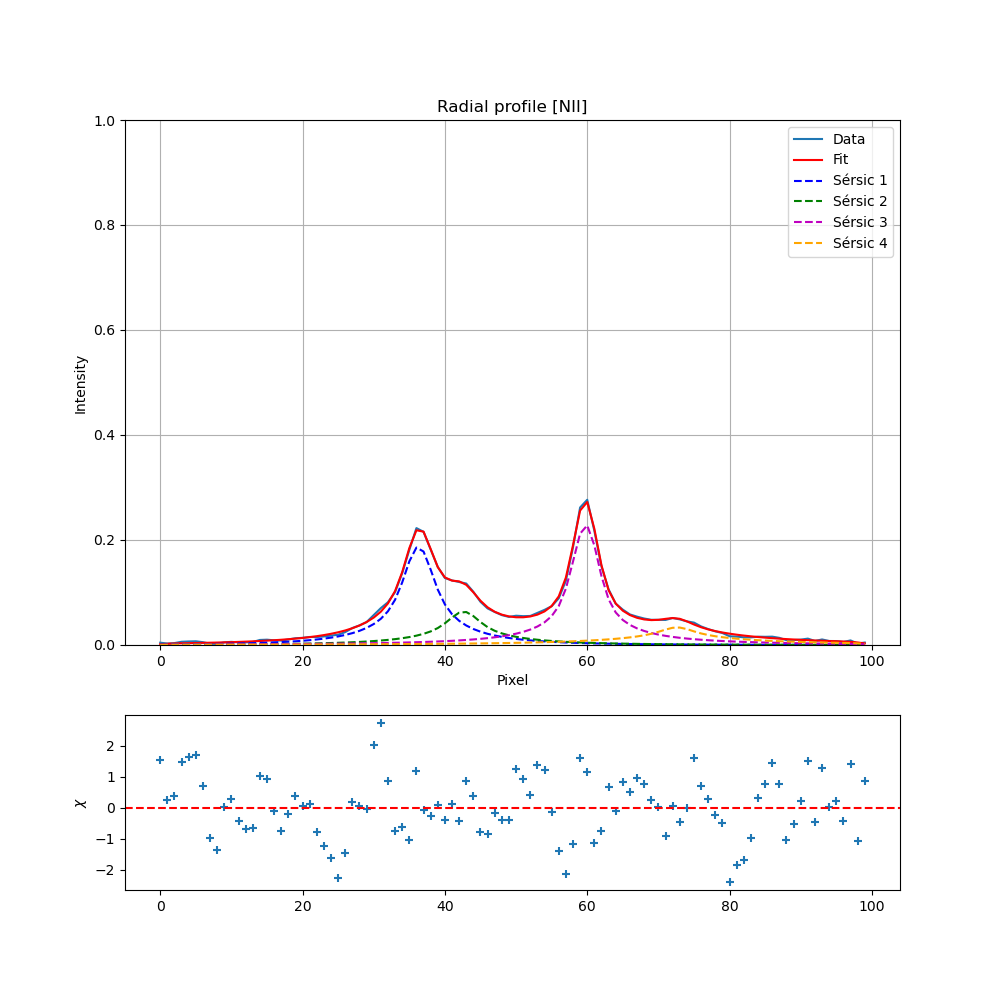

In [28]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_NII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_NII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [NII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].scatter(x_axes, (radial_profile_NII - y_fit)/radial_profile_error_NII, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

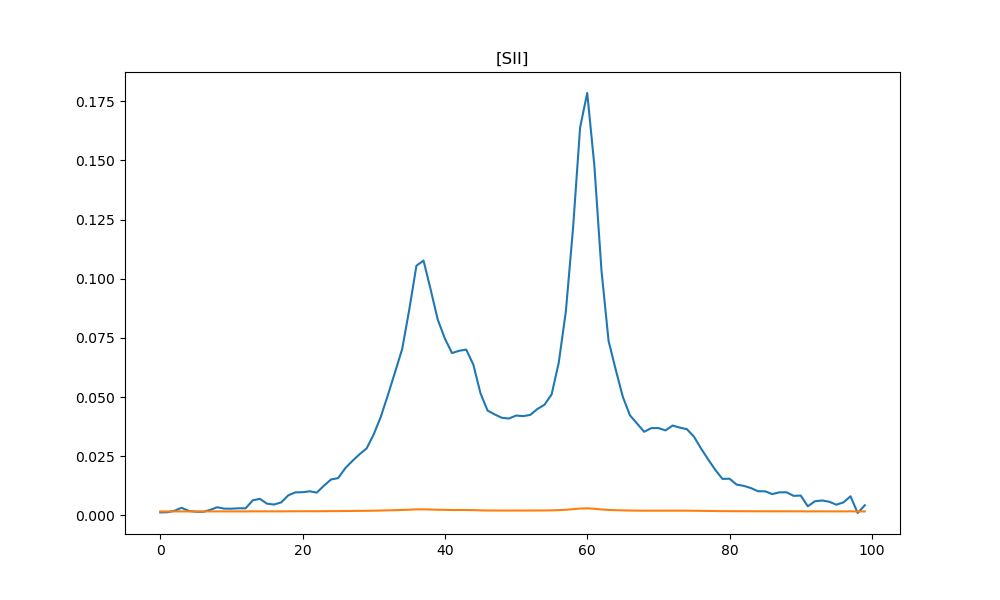

In [29]:
mask_SII = (wavelenghts > l_SII-10)*(wavelenghts < l_SII+10)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.mean(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))/image_error_SII.shape[1]
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [30]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1.6244790009221943
differential_evolution step 2: f(x)= 0.6153858919201284
differential_evolution step 3: f(x)= 0.6006594276682092
differential_evolution step 4: f(x)= 0.048497483908737246
differential_evolution step 5: f(x)= 0.048497483908737246
differential_evolution step 6: f(x)= 0.048497483908737246
differential_evolution step 7: f(x)= 0.048497483908737246
differential_evolution step 8: f(x)= 0.048497483908737246
differential_evolution step 9: f(x)= 0.048497483908737246
differential_evolution step 10: f(x)= 0.03141540183986888
differential_evolution step 11: f(x)= 0.03141540183986888
differential_evolution step 12: f(x)= 0.03141540183986888
differential_evolution step 13: f(x)= 0.03141540183986888
differential_evolution step 14: f(x)= 0.014489024769099839
differential_evolution step 15: f(x)= 0.014489024769099839
differential_evolution step 16: f(x)= 0.014489024769099839
differential_evolution step 17: f(x)= 0.014489024769099839
differential_evo

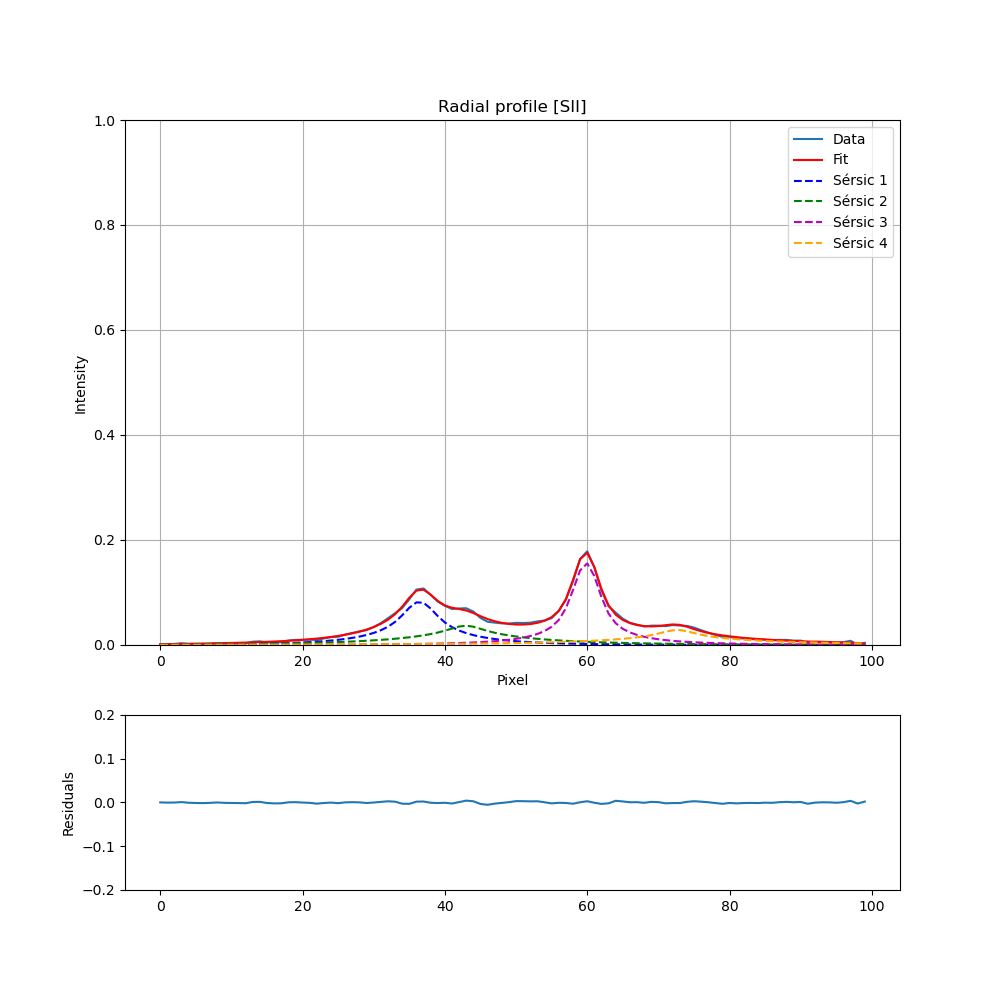

In [31]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_SII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [SII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0,1)

ax[1].plot(x_axes, radial_profile_SII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')
plt.savefig('Radial_profile_SII_diff')

In [32]:
params_curve_SII, covariance_SII = curve_fit(model_convolved, x_axes, radial_profile_SII, p0=result.x, sigma = radial_profile_error_SII)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_SII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_SII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("SII_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_SII)))
#print(infodict.fvec**2)
chi2_SII = np.sum((((radial_profile_SII - model_convolved(x_axes, *params_curve_SII)) / radial_profile_error_SII)**2))
dof_SII = len(radial_profile_SII) - len(params_curve_SII)
chi2_reduced_SII = chi2_SII / dof_SII
print(chi2_reduced_SII)

Sérsic 1: I_e=0.0093, r_e=11.6882, n=1.5046, x_0=36.4347
Sérsic 2: I_e=0.0041, r_e=20.0288, n=1.3709, x_0=42.8351
Sérsic 3: I_e=0.0058, r_e=15.6561, n=2.4737, x_0=59.7862
Sérsic 4: I_e=0.0018, r_e=33.7764, n=1.7465, x_0=72.8742
[3.52363511e-03 4.67222884e+00 2.57209446e-01 9.81413224e-02
 1.99494736e-03 1.27723197e+01 2.83819762e-01 3.69418569e-01
 1.29773624e-02 2.71357690e+01 1.96664919e+00 1.63778667e-02
 9.22360281e-04 1.65567114e+01 3.18110832e-01 2.56744011e-01]
0.9507458327004611


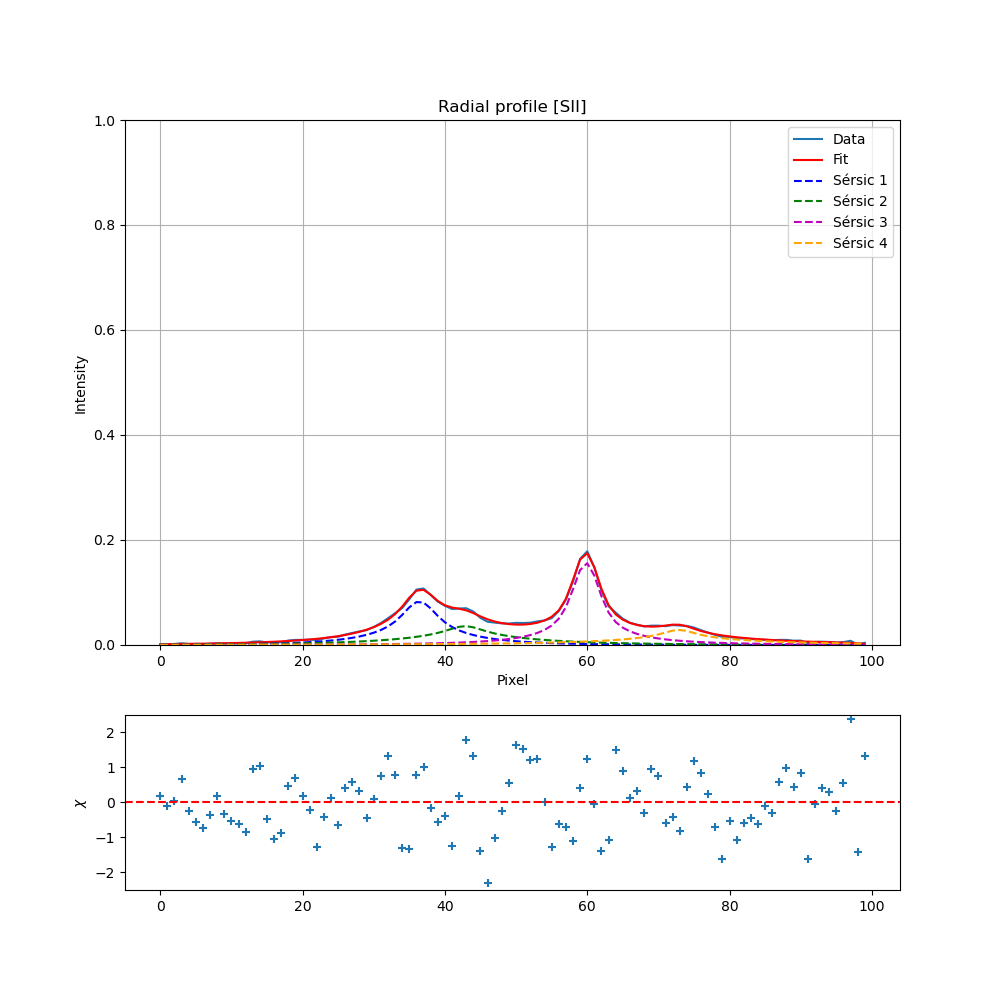

In [33]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_SII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_SII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [SII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].scatter(x_axes, (radial_profile_SII - y_fit)/radial_profile_error_SII,marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
ax[1].set_ylim(-2.5, 2.5)
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

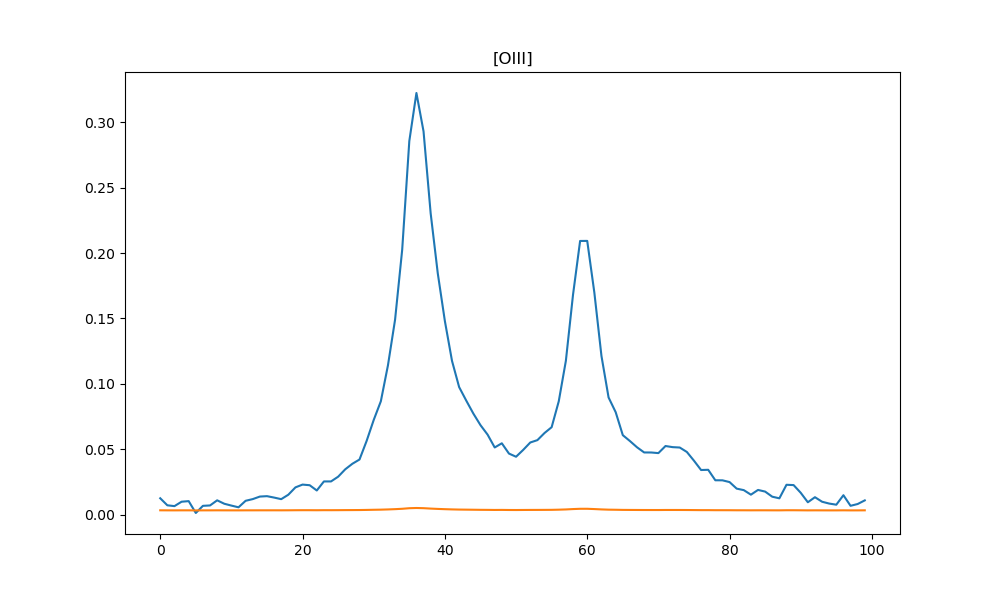

In [44]:
mask_OIII = (wavelenghts > l_OIII-10)*(wavelenghts < l_OIII+10)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.mean(image_OIII, axis = 1) 
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))/image_error_OIII.shape[1]
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [45]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 0.7910335059849987
differential_evolution step 2: f(x)= 0.5105923982647844
differential_evolution step 3: f(x)= 0.5105923982647844
differential_evolution step 4: f(x)= 0.5105923982647844
differential_evolution step 5: f(x)= 0.16614311897039696
differential_evolution step 6: f(x)= 0.11076065986865108
differential_evolution step 7: f(x)= 0.11076065986865108
differential_evolution step 8: f(x)= 0.10338229505052726
differential_evolution step 9: f(x)= 0.10338229505052726
differential_evolution step 10: f(x)= 0.10338229505052726
differential_evolution step 11: f(x)= 0.10338229505052726
differential_evolution step 12: f(x)= 0.1031192985013129
differential_evolution step 13: f(x)= 0.1031192985013129
differential_evolution step 14: f(x)= 0.06682220051387586
differential_evolution step 15: f(x)= 0.06682220051387586
differential_evolution step 16: f(x)= 0.06682220051387586
differential_evolution step 17: f(x)= 0.0450298565248474
differential_evolution step 18

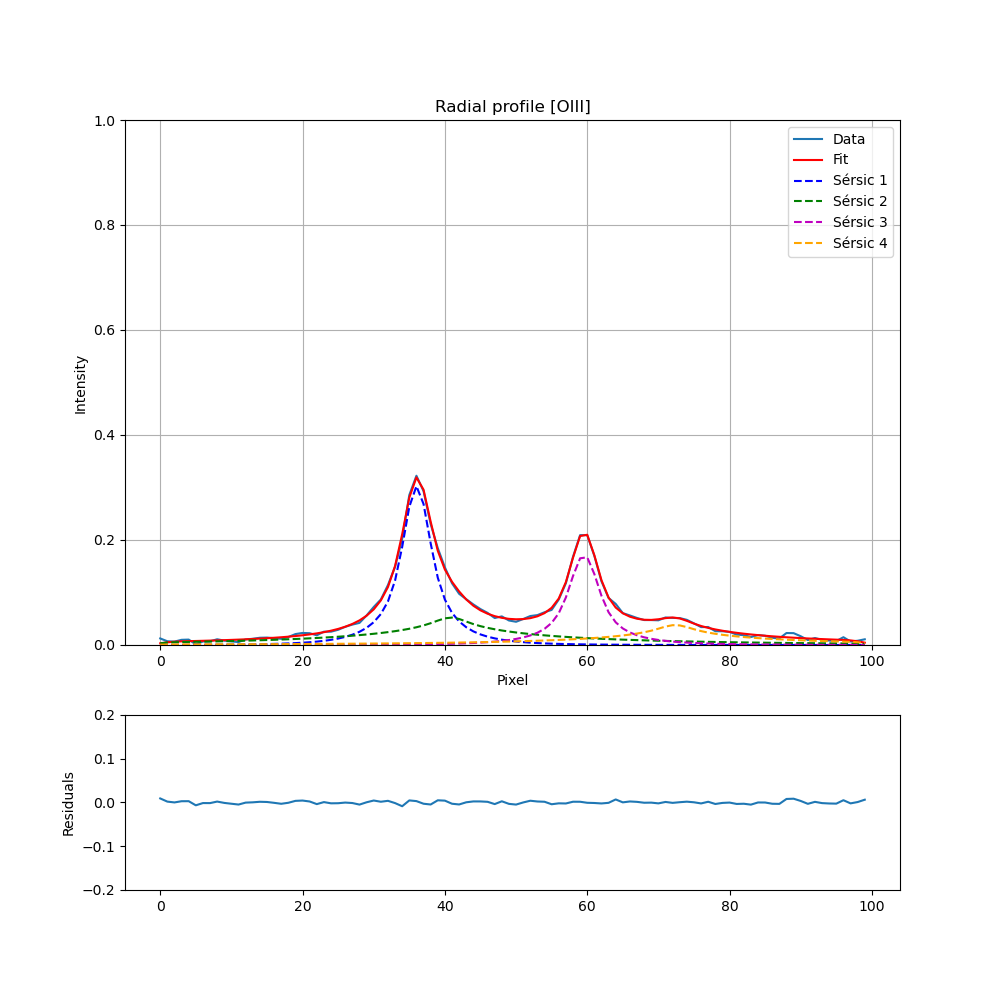

In [46]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_OIII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [OIII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].plot(x_axes, radial_profile_OIII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')

plt.savefig('Radial_profile_OIII_kernel')

In [47]:
params_curve_OIII, covariance_OIII = curve_fit(model_convolved, x_axes, radial_profile_OIII, p0=result.x, sigma = radial_profile_error_OIII)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_OIII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_OIII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("OIII_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_OIII)))
#print(infodict.fvec**2)
chi2_OIII = np.sum((((radial_profile_OIII - model_convolved(x_axes, *params_curve_OIII)) / radial_profile_error_OIII)**2))
dof_OIII = len(radial_profile_OIII) - len(params_curve_OIII)
chi2_reduced_OIII = chi2_OIII / dof_OIII
print(chi2_reduced_OIII)

Sérsic 1: I_e=0.0263, r_e=7.8410, n=1.7731, x_0=36.0203
Sérsic 2: I_e=0.0035, r_e=35.1690, n=1.6726, x_0=40.0690
Sérsic 3: I_e=0.0078, r_e=13.9961, n=2.4075, x_0=59.5455
Sérsic 4: I_e=0.0005, r_e=219.0441, n=2.6633, x_0=72.4570
[1.48208291e-02 3.27297727e+00 5.64045161e-01 2.90118942e-02
 3.06494545e-03 2.39220201e+01 4.95687675e-01 4.91391803e-01
 6.29601126e-03 9.47482678e+00 5.79389467e-01 3.85249105e-02
 8.08870494e-04 3.65282740e+02 1.01268221e+00 3.08944902e-01]
0.9688037434722625


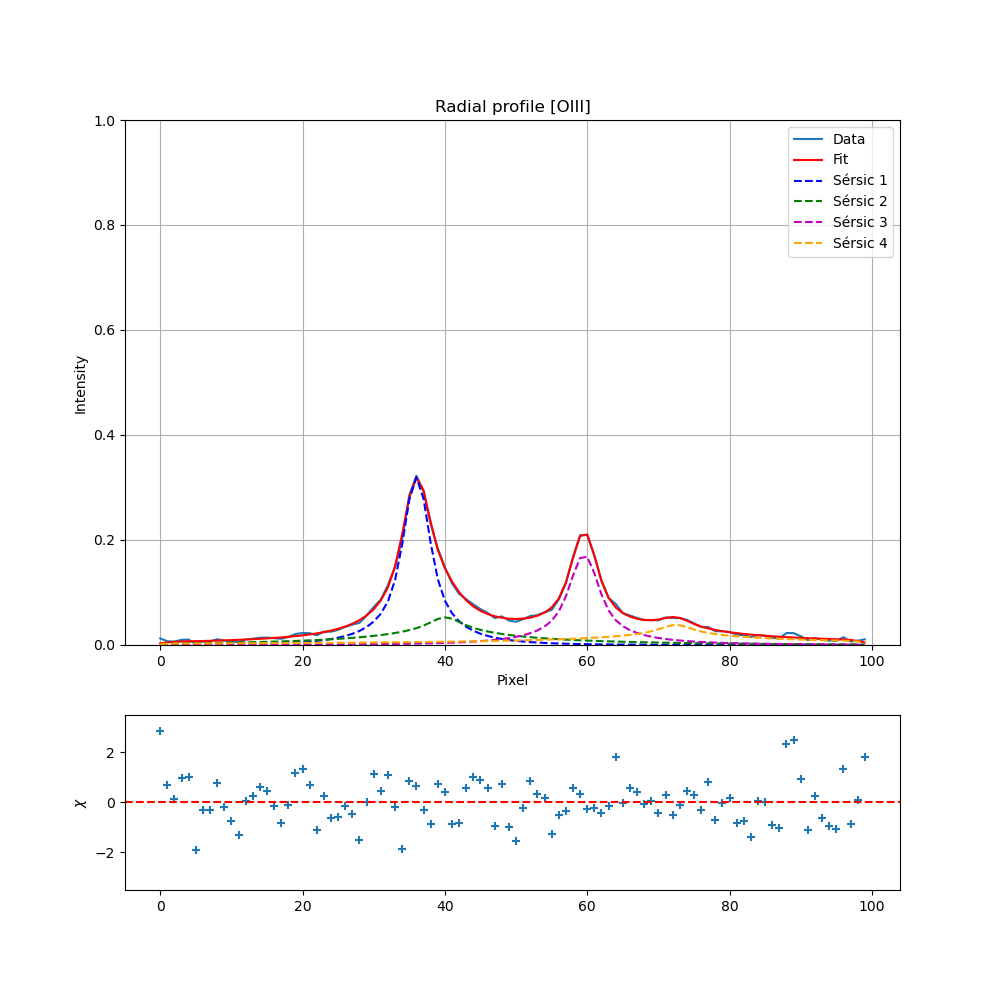

In [48]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_OIII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_OIII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [OIII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].scatter(x_axes, (radial_profile_OIII - y_fit)/radial_profile_error_OIII, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
ax[1].set_ylim(-3.5, 3.5)
plt.savefig('Radial_profile_OIII_curve')

In [49]:
radial_profile_OIII - y_fit

array([ 9.40237668e-03,  2.23045664e-03,  4.35699756e-04,  3.22445055e-03,
        3.31768074e-03, -6.07878813e-03, -9.39170157e-04, -1.01437270e-03,
        2.50438122e-03, -5.44074057e-04, -2.43136242e-03, -4.26393142e-03,
        1.36771821e-04,  7.90869724e-04,  2.02524562e-03,  1.54753700e-03,
       -4.20611541e-04, -2.62891559e-03, -3.72980051e-04,  3.94179303e-03,
        4.58361668e-03,  2.36292151e-03, -3.69279356e-03,  8.20513488e-04,
       -2.05111082e-03, -1.92119962e-03, -5.31552816e-04, -1.64619935e-03,
       -5.21299792e-03,  1.14121149e-04,  4.27633958e-03,  1.79916862e-03,
        4.28337361e-03, -7.02868993e-04, -8.36330059e-03,  4.18933694e-03,
        3.26288816e-03, -1.42257287e-03, -3.93855520e-03,  3.23646969e-03,
        1.80042015e-03, -3.39853282e-03, -3.14480599e-03,  2.26782345e-03,
        3.86531990e-03,  3.35063589e-03,  2.11527122e-03, -3.40718723e-03,
        2.68450477e-03, -3.47412802e-03, -5.34453877e-03, -7.32272164e-04,
        3.02505149e-03,  

In [50]:
radial_profile_error_OIII

array([0.00328881, 0.00325171, 0.00324093, 0.00326407, 0.00326558,
       0.00320621, 0.00324611, 0.00325195, 0.00327932, 0.00325779,
       0.00324601, 0.00324067, 0.0032691 , 0.00326981, 0.00328308,
       0.00328081, 0.00328829, 0.00327413, 0.00329937, 0.00334397,
       0.00337295, 0.0033701 , 0.00333688, 0.00338698, 0.00337516,
       0.00339826, 0.00343864, 0.00346416, 0.00349624, 0.00358262,
       0.00369403, 0.00378818, 0.00395473, 0.0041688 , 0.00445207,
       0.0048889 , 0.00505321, 0.00491518, 0.00460093, 0.00435125,
       0.00414717, 0.00397703, 0.00385325, 0.00378877, 0.00372516,
       0.00365255, 0.00361689, 0.00355772, 0.00359273, 0.0035305 ,
       0.00350495, 0.00354538, 0.00357619, 0.00358818, 0.00361542,
       0.00364716, 0.00377105, 0.0039486 , 0.00423298, 0.00444464,
       0.00445154, 0.00423344, 0.00397096, 0.00378037, 0.00370594,
       0.00360187, 0.00356973, 0.00354181, 0.0035144 , 0.003507  ,
       0.00350097, 0.00353889, 0.00353831, 0.00353236, 0.00350